# Impostor
Problema por Ícaro Fróes
> 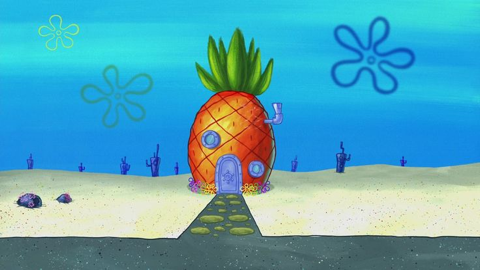
>
> Bob Esponja guarda com carinho um diário precioso, com a foto de todos os seus amigos. Mas, ao voltar para casa depois de um longo dia de trabalho no Siri Cascudo, ele encontrou uma carta do Lula Molusco em cima do diário:
>
> *"Como você me irrita tanto, decidi te irritar também. Arranquei 10 páginas aleatórias do seu diário e coloquei impostoras no lugar. Agora o seu diário está incompleto, e você nunca vai saber onde!"*
>
> Desesperado, Bob Esponja pediu a sua ajuda. **Treine um modelo que encontre as páginas impostoras automaticamente.**

## Descrição da tarefa

O diário tem **3.000 páginas** contendo imagens dos personagens:
- Bob Esponja Calça Quadrada (SpongeBob SquarePants)
- Patrick Estrela (Patrick Star)
- Lula Molusco (Squidward Tentacles)
- Seu Siriguejo (Mr. Krabs)
- Plankton (Plankton)
- Gary (Gary the Snail) 

Cada página é uma imagem contendo 3 fotos de um único personagem. Exatamente **10** delas são impostoras: imagens que não pertencem ao diário original.

Não há conjunto de treino rotulado. Você precisa descobrir, apenas a partir das próprias imagens, quais páginas destoam das demais.

## Entrada

- `data/book.zip`: contém `book/0001.jpg` a `book/3000.jpg`, ou seja, 3.000 imagens JPEG
- `data/book_ans.csv`: as 10 páginas impostoras do livro público (coluna `page`)
- `data/book_hidden.zip` e `data/book_hidden_ans.csv`: o livro oculto da avaliação e as suas respostas, usados só na última célula

Os livros têm cerca de 1,1 GB cada e ficam nos [releases do repositório](https://github.com/NOIC-IA/oboia/releases/tag/oboia-2026-impostor). Se eles não estiverem em `data/`, o notebook baixa automaticamente.

Na avaliação, o livro oculto (que contém páginas e impostores diferentes) terá o mesmo caminho de `book.zip`, nada precisa ser alterado.

## Saída

O programa deve criar um arquivo `predictions.csv` com **exatamente 10 linhas**, uma por página suspeita:

```csv
page
0042
1337
...
```

`page` é o número da página, igual ao nome do arquivo (de `0001` a `3000`). Páginas repetidas não contam duas vezes.

## Avaliação

Seja $k$ o número de **páginas impostoras distintas** que aparecem no seu `predictions.csv`. A pontuação cresce **exponencialmente** com $k$, então cada impostora a mais vale mais do que a anterior:

$$\text{score} = \frac{2^{k} - 1}{2^{10} - 1}$$

<table align="center" style="text-align: center">
  <tr><th>Impostoras encontradas (<i>k</i>)</th><th>Score</th></tr>
  <tr><td>0</td><td>0,000</td></tr>
  <tr><td>1</td><td>0,001</td></tr>
  <tr><td>2</td><td>0,003</td></tr>
  <tr><td>3</td><td>0,007</td></tr>
  <tr><td>4</td><td>0,015</td></tr>
  <tr><td>5</td><td>0,030</td></tr>
  <tr><td>6</td><td>0,062</td></tr>
  <tr><td>7</td><td>0,124</td></tr>
  <tr><td>8</td><td>0,249</td></tr>
  <tr><td>9</td><td>0,499</td></tr>
  <tr><td><b>10</b></td><td><b>1,000</b></td></tr>
</table>

Cada impostora a mais **dobra** (aproximadamente) a sua pontuação. Encontrar a 10ª vale tanto quanto todas as outras nove juntas.

- Só as **10 primeiras linhas** do arquivo são consideradas. As linhas a mais são ignoradas.
- Uma página repetida conta **uma vez só**.
- `0042` e `42` são a mesma página.
- Se o arquivo não tiver a coluna `page`, ou se tiver uma página fora do intervalo de `1` a `3000`, a submissão é considerada **inválida**.

No leaderboard oculto, o baseline obteve `0,00`, e o melhor score atingido pelo departamento do NOIC foi `1,00`.

## Submissão

Envie um arquivo ZIP com **exatamente um** notebook (`.ipynb`) na raiz. O notebook será executado do início ao fim, em um ambiente com GPU, sobre o livro oculto de 3.000 páginas. Ao terminar, ele deve ter criado o arquivo `predictions.csv`:

```csv
page
0042
1337
...
```

- O arquivo tem **10 linhas** com as páginas suspeitas, além do cabeçalho `page`.
- Os números das páginas seguem o nome dos arquivos, de `0001` a `3000`.
- **Não** envie uma lista de páginas calculada antes: a avaliação roda o seu código.
- **Não** inclua o livro, nem pesos de modelos muito grandes, no ZIP.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from transformers import CLIPModel, CLIPProcessor

### Carregando os dados
São muitas imagens, então elas vêm num ZIP só, em `data/book.zip`. Se ele ainda não estiver lá (por exemplo, no Colab ou no Kaggle), a gente baixa o livro público e as respostas dele (`data/book_ans.csv`) primeiro. No Kaggle, ative a opção **Internet** nas configurações do notebook para o download funcionar.

Na avaliação, o livro oculto já vem em `data/book.zip` e não há arquivo de respostas, então nada é baixado.

In [2]:
import shutil
import urllib.request

DATA = "data"
BOOK_ZIP = f"{DATA}/book.zip"
ANSWERS = f"{DATA}/book_ans.csv"

BOOK_URL = "https://github.com/NOIC-IA/oboia/releases/download/oboia-2026-impostor/book.zip"
ANSWERS_URL = "https://github.com/NOIC-IA/oboia/releases/download/oboia-2026-impostor/book_ans.csv"


def baixar(url, destino):
    # O servidor do livro recusa o User-Agent padrão do Python (erro 403), então nos identificamos.
    pedido = urllib.request.Request(url, headers={"User-Agent": "oboia-notebook/1.0"})
    with urllib.request.urlopen(pedido) as resposta, open(destino + ".part", "wb") as arquivo:
        shutil.copyfileobj(resposta, arquivo, length=1024 * 1024)
    os.replace(destino + ".part", destino)  # só renomeia quando o download terminou


# Na avaliação, o livro oculto já está em data/book.zip: só baixamos quando o arquivo não existe.
if not os.path.exists(BOOK_ZIP):
    os.makedirs(DATA, exist_ok=True)
    print("Baixando book.zip (cerca de 1,1 GB)...")
    baixar(BOOK_URL, BOOK_ZIP)
    if not os.path.exists(ANSWERS):
        baixar(ANSWERS_URL, ANSWERS)

Agora descompactamos o livro uma vez só em `data/book/` (se a pasta já existe, pulamos). Usamos o `zipfile` do Python, que funciona em qualquer sistema, sem precisar do comando `unzip`.

In [3]:
import zipfile

IMAGES_PATH = f"{DATA}/book"

if not os.path.isdir(IMAGES_PATH):
    with zipfile.ZipFile(BOOK_ZIP) as livro:
        livro.extractall(DATA)

### Carregando o CLIP
O CLIP é um modelo que coloca textos e imagens no mesmo espaço latente, perfeito pro que a gente quer aqui: comparar páginas com descrições em texto.

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device).eval()

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 72963.55it/s]

Vamos guardar também o caminho da pasta e de cada imagem, pra usar depois. Elas são nomeadas pelo índice, de 0001.jpg a 3000.jpg.

In [5]:
ALL_IMAGES_PATH = [f"{IMAGES_PATH}/{i:04d}.jpg" for i in range(1, len(os.listdir(IMAGES_PATH)) + 1)]

### A abordagem
A ideia é ter um prompt pra cada personagem do Bob Esponja que aparece no diário e comparar cada página com todos eles. Uma página do Patrick, por exemplo, deveria ter uma similaridade bem alta com o prompt "Patrick Star". Os prompts ficam em inglês, que é o que o CLIP entende melhor.

Depois é só pegar as páginas que pior combinam com qualquer personagem, torcendo pra que os impostores estejam entre elas.

In [6]:
prompts = [
    "SpongeBob SquarePants",
    "Patrick Star",
    "Squidward Tentacles",
    "Mr. Krabs",
    "Plankton",
    "Gary the Snail"
]

### Embeddings dos textos
Vamos usar o CLIP pra gerar os embeddings dos textos.

In [7]:
text = processor(text=prompts, return_tensors="pt", padding=True).to(device)
with torch.inference_mode():
    outputs = model.get_text_features(**text)
    text_embeddings = outputs.pooler_output
    text_embeddings /= text_embeddings.norm(dim=1, keepdim=True)

text_embeddings.shape

torch.Size([6, 512])

### Recortando as polaroids
Cada página tem três polaroids sempre nas mesmas posições, então recortamos só elas pro CLIP focar nos personagens e não na decoração. Dá pra conferir um dos recortes aqui.

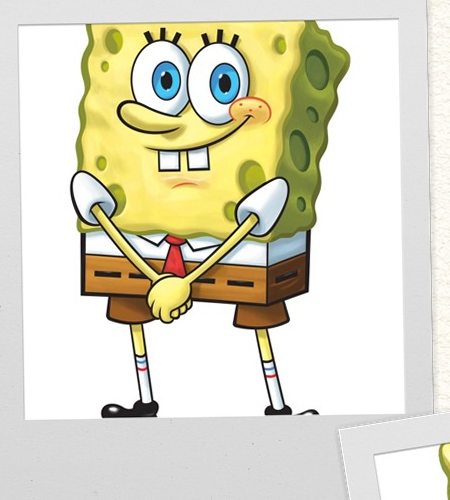

In [8]:
sample_image_path = ALL_IMAGES_PATH[1]

with Image.open(sample_image_path) as sample_image:
    sample_image = sample_image.convert('RGB')

crop_a = (150, 100, 600, 600)
crop_b = (500, 500, 1000, 1000)
crop_c = (150, 900, 600, 1400)

crops = (crop_a, crop_b, crop_c)
sample_image.crop(crop_a)

### Embeddings das imagens
E agora o mesmo pras imagens, em batches. Cada página vira três recortes, um por polaroid.

In [9]:
BATCH_SIZE = 128
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if DEVICE == "cuda" else torch.float32

feature_batches = []

for start in range(0, len(ALL_IMAGES_PATH), BATCH_SIZE):
    images = []

    # Abre as imagens em RGB
    for index, path in enumerate(ALL_IMAGES_PATH[start:start + BATCH_SIZE], start):
        with Image.open(path) as image:
            image = image.convert('RGB')
            # O layout alterna de lado entre páginas, então espelhamos as de índice par
            # (arquivos 0001, 0003, ...)
            # pra que os mesmos recortes sirvam pra todas
            if index % 2 == 0:
                image = image.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
            for crop in crops:
                images.append(image.crop(crop))

    # Aplica o pré-processamento do CLIP pra que as imagens possam entrar no modelo
    pixels = processor(
        images=images,
        return_tensors='pt'
    )['pixel_values'].to(DEVICE, dtype=dtype)

    # Extrai os embeddings com o CLIP e normaliza cada um
    with torch.inference_mode():
        outputs = model.get_image_features(pixel_values=pixels)
        image_features = outputs.pooler_output
        image_features = image_features / image_features.norm(dim=1, keepdim=True)

    feature_batches.append(image_features.float().cpu().numpy())

    # Mostra o progresso a cada 5 batches
    if start and start % (BATCH_SIZE * 5) == 0:
        print(f'{start}/{len(ALL_IMAGES_PATH)} images embedded')

image_embeddings = np.concatenate(feature_batches)

image_embeddings.shape

640/3000 images embedded


1280/3000 images embedded


1920/3000 images embedded


2560/3000 images embedded


(9000, 512)

### Calculando a similaridade
Agora dá pra usar o operador `@`, que faz o produto escalar entre todos os embeddings de imagem e de texto. Como tudo está normalizado, isso é a similaridade de cosseno.

O resultado tem shape `(9000, 6)`: 3 recortes para cada uma das 3000 páginas, com 6 scores cada, um por prompt. Depois agrupamos os recortes de cada página e somamos, ficando com `(3000, 6)`.

In [10]:
all_scores = image_embeddings @ text_embeddings.cpu().numpy().T
scores_per_image = all_scores.reshape(-1, 3, all_scores.shape[1])
summed_scores = scores_per_image.sum(axis=1)

Agora pegamos o `argmax()` de cada página, que é o índice do prompt com maior score. Numa página do Plankton, por exemplo, o maior score provavelmente vai ser o do prompt "Plankton", e é só esse que importa pra aquela página.

In [11]:
best = summed_scores.argmax(axis=1)

best

array([1, 0, 1, ..., 0, 5, 1], shape=(3000,))

Vamos dar uma olhada em todos os scores. A coluna `best` é o maior score de cada página e `best_idx` é o personagem correspondente.

In [12]:
scores = pd.DataFrame(summed_scores)

scores['best'] = summed_scores[
    np.arange(len(summed_scores)),
    best
]

scores['best_idx'] = best

scores

,0,1,2,3,4,5,best,best_idx
0,0.832873,0.961955,0.762400,0.784718,0.817252,0.715774,0.961955,1
1,0.922829,0.805742,0.788159,0.776530,0.807878,0.693700,0.922829,0
2,0.793233,0.918454,0.769767,0.793084,0.785510,0.716977,0.918454,1
3,0.811683,0.768453,0.944570,0.790427,0.842163,0.735274,0.944570,2
4,0.912598,0.804858,0.800771,0.794736,0.789659,0.728867,0.912598,0
...,...,...,...,...,...,...,...,...
2995,0.904258,0.788560,0.764442,0.761508,0.785657,0.701608,0.904258,0
2996,0.803305,0.792878,0.861314,0.822385,0.862971,0.876773,0.876773,5
2997,0.889704,0.794589,0.777584,0.755700,0.798506,0.683062,0.889704,0
2998,0.759036,0.752693,0.810485,0.794237,0.831582,0.841242,0.841242,5


### Os piores scores
E agora os piores. Com sorte, os impostores estão entre eles.

In [13]:
worst_scores = scores.sort_values("best", ascending=True).head(10)

worst_scores

,0,1,2,3,4,5,best,best_idx
1577,0.558101,0.523217,0.520505,0.553093,0.577445,0.582246,0.582246,5
927,0.527657,0.515921,0.565509,0.586783,0.617984,0.528528,0.617984,4
633,0.586560,0.617497,0.575275,0.596232,0.547878,0.627062,0.627062,5
1168,0.638946,0.641736,0.611069,0.605420,0.571125,0.621137,0.641736,1
2999,0.576501,0.651912,0.622433,0.642091,0.514433,0.638958,0.651912,1
117,0.685214,0.647171,0.678540,0.650336,0.667979,0.684675,0.685214,0
1837,0.561434,0.567597,0.664822,0.601360,0.740003,0.581933,0.740003,4
1495,0.747863,0.676944,0.631009,0.660428,0.690286,0.618577,0.747863,0
1928,0.692992,0.701606,0.727827,0.642453,0.749023,0.714721,0.749023,4
686,0.685167,0.769118,0.672180,0.687263,0.618394,0.655703,0.769118,1


Vamos plotar e conferir no olho.

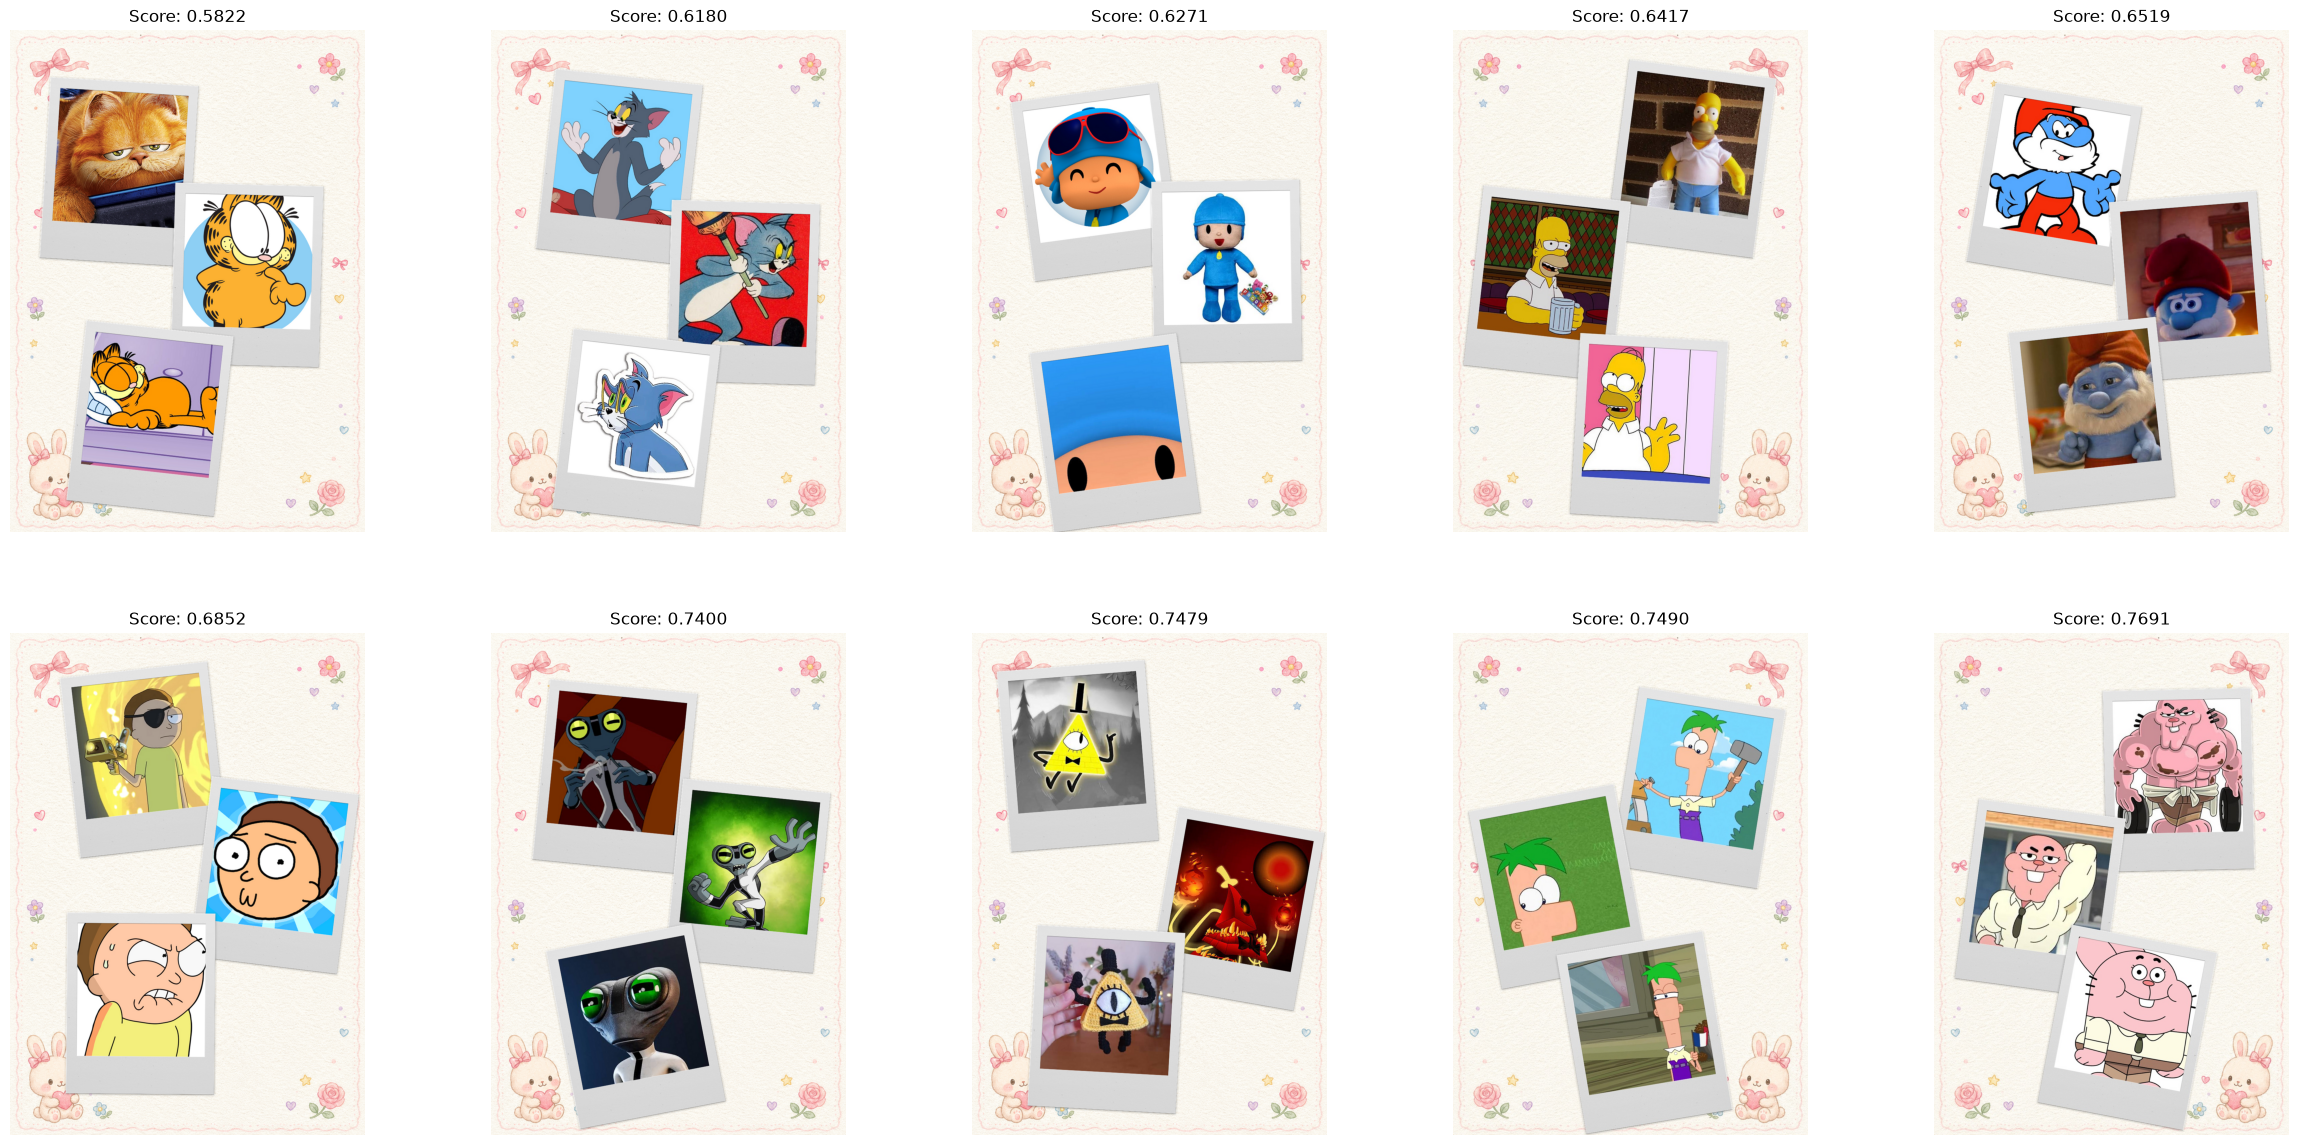

In [14]:
plt.figure(figsize=(30, 30))

for i, idx in enumerate(worst_scores.index):
    img = plt.imread(f"{IMAGES_PATH}/{idx + 1:04d}.jpg")
    plt.subplot(4, 5, i + 1)
    plt.imshow(img)
    plt.title(f"Score: {worst_scores.loc[idx, 'best']:.4f}")
    plt.axis("off")

plt.show()

### Salvando as predições
Por fim, salvamos as 10 candidatas em `predictions.csv`, uma por linha, na coluna `page`. O número da página é o mesmo do nome do arquivo (de `0001` a `3000`).

In [15]:
# Os índices começam em 0, então o número da página é índice + 1
pages = [f"{int(idx) + 1:04d}" for idx in worst_scores.index]

predictions = pd.DataFrame({"page": pages})
predictions.to_csv("predictions.csv", index=False)

predictions

,page
0,1578
1,0928
2,0634
3,1169
4,3000
5,0118
6,1838
7,1496
8,1929
9,0687


### Avaliação local
Quando `data/book_ans.csv` está disponível (no kit inicial, ou quando o notebook baixou o livro público), calculamos o score como na avaliação: $k$ é o número de páginas impostoras distintas entre as 10 primeiras linhas de `predictions.csv`, e

$$\text{score} = \frac{2^{k} - 1}{2^{10} - 1}$$

Na avaliação privada esse arquivo não existe, então a célula apenas segue adiante, sem lançar nenhuma exceção.

In [16]:
if os.path.exists(ANSWERS):
    impostoras = set(pd.read_csv(ANSWERS, dtype=str)["page"].astype(int))
    previstas = set(pd.read_csv("predictions.csv", dtype=str)["page"].head(10).astype(int))  # "0042" e "42" são a mesma página

    k = len(previstas & impostoras)
    score = (2**k - 1) / (2**10 - 1)

    print(f"Impostoras encontradas: {k} de 10")
    print(f"Score no livro público: {score:.3f}")

Impostoras encontradas: 10 de 10
Score no livro público: 1.000


### Bônus: score no livro oculto
Isto não fazia parte da prova: rodamos o mesmo método no livro oculto usado na avaliação (`data/book_hidden.zip`) e comparamos com as respostas dele (`data/book_hidden_ans.csv`). Se os arquivos não estiverem em `data/`, a célula baixa dos releases do repositório.

In [17]:
HIDDEN_ZIP = f"{DATA}/book_hidden.zip"
HIDDEN_ANSWERS = f"{DATA}/book_hidden_ans.csv"
HIDDEN_DIR = f"{DATA}/hidden"

if not os.path.exists(HIDDEN_ZIP):
    print("Baixando book_hidden.zip (cerca de 1,1 GB)...")
    baixar("https://github.com/NOIC-IA/oboia/releases/download/oboia-2026-impostor/book_hidden.zip", HIDDEN_ZIP)
if not os.path.exists(HIDDEN_ANSWERS):
    baixar("https://github.com/NOIC-IA/oboia/releases/download/oboia-2026-impostor/book_hidden_ans.csv", HIDDEN_ANSWERS)
if not os.path.isdir(f"{HIDDEN_DIR}/book"):
    with zipfile.ZipFile(HIDDEN_ZIP) as livro:
        livro.extractall(HIDDEN_DIR)

paginas_ocultas = [f"{HIDDEN_DIR}/book/{i:04d}.jpg" for i in range(1, len(os.listdir(f"{HIDDEN_DIR}/book")) + 1)]

# Mesmo pipeline da solução: recortes das polaroids, similaridade com os prompts e os 10 piores scores.
lotes = []
for start in range(0, len(paginas_ocultas), BATCH_SIZE):
    imagens = []
    for index, path in enumerate(paginas_ocultas[start:start + BATCH_SIZE], start):
        with Image.open(path) as image:
            image = image.convert("RGB")
            if index % 2 == 0:
                image = image.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
            for crop in crops:
                imagens.append(image.crop(crop))
    pixels = processor(images=imagens, return_tensors="pt")["pixel_values"].to(DEVICE, dtype=dtype)
    with torch.inference_mode():
        features = model.get_image_features(pixel_values=pixels).pooler_output
        features = features / features.norm(dim=1, keepdim=True)
    lotes.append(features.float().cpu().numpy())
embeddings_ocultos = np.concatenate(lotes)

scores_ocultos = (embeddings_ocultos @ text_embeddings.cpu().numpy().T).reshape(-1, 3, len(prompts)).sum(axis=1)
melhor_score = scores_ocultos.max(axis=1)
previstas_ocultas = {int(i) + 1 for i in np.argsort(melhor_score, kind="stable")[:10]}

impostoras_ocultas = set(pd.read_csv(HIDDEN_ANSWERS, dtype=str)["page"].astype(int))
k_oculto = len(previstas_ocultas & impostoras_ocultas)

print(f"Impostoras encontradas no livro oculto: {k_oculto} de 10")
print(f"Score no livro oculto: {(2**k_oculto - 1) / (2**10 - 1):.3f}")

Impostoras encontradas no livro oculto: 10 de 10
Score no livro oculto: 1.000
